In [3]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

In [4]:
raw_df=pd.read_csv('train.csv')
#Let's normalize the quantitative features
df=raw_df
df['person_age']=(df['person_age']-df['person_age'].mean())/df['person_age'].std()
df['person_income']=(df['person_income']-df['person_income'].mean())/df['person_income'].std()
df['person_emp_length']=(df['person_emp_length']-df['person_emp_length'].mean())/df['person_emp_length'].std()
df['loan_amnt']=(df['loan_amnt']-df['loan_amnt'].mean())/df['loan_amnt'].std()
df['loan_int_rate']=(df['loan_int_rate']-df['loan_int_rate'].mean())/df['loan_int_rate'].std()
df['loan_percent_income']=(df['loan_percent_income']-df['loan_percent_income'].mean())/df['loan_percent_income'].std()
df['cb_person_cred_hist_length']=(df['cb_person_cred_hist_length']-df['cb_person_cred_hist_length'].mean())/df['cb_person_cred_hist_length'].std()

In [5]:
df[['loan_intent']].value_counts()
#df.head()

loan_intent      
EDUCATION            12271
MEDICAL              10934
PERSONAL             10016
VENTURE              10011
DEBTCONSOLIDATION     9133
HOMEIMPROVEMENT       6280
Name: count, dtype: int64

In [6]:
#X_train, X_test, y_train, y_test = train_test_split(X, y,
#                                                       shuffle = True,
#                                                       random_state = 440,
#                                                       test_size = .2)
#
#
#bb_train, bb_test = train_test_split(baseball.copy(),
#                                        random_state = 614,
#                                        shuffle = True,
#                                        test_size=.2)
df_train, df_test=train_test_split(df.copy(), shuffle=True, random_state=42, test_size=.2)

In [7]:
df_train.head()

,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
14337,14337,1.400438,-0.370307,RENT,-1.187190,HOMEIMPROVEMENT,C,-0.362622,1.045286,-0.209806,Y,2.279969,0
17117,17117,-0.091304,-0.549580,RENT,-0.429573,DEBTCONSOLIDATION,C,-0.758034,0.323632,-0.427928,Y,0.790839,0
32590,32590,-0.422802,0.156964,MORTGAGE,-1.187190,EDUCATION,A,-0.218835,-0.921962,-0.536989,N,-0.698292,0
55811,55811,1.897685,0.288782,MORTGAGE,-0.682112,DEBTCONSOLIDATION,A,1.039296,-1.363521,0.444560,N,1.287216,0
40120,40120,-0.920049,-0.486307,RENT,0.075505,MEDICAL,A,-0.937767,-0.994457,-0.755111,N,-0.946481,0


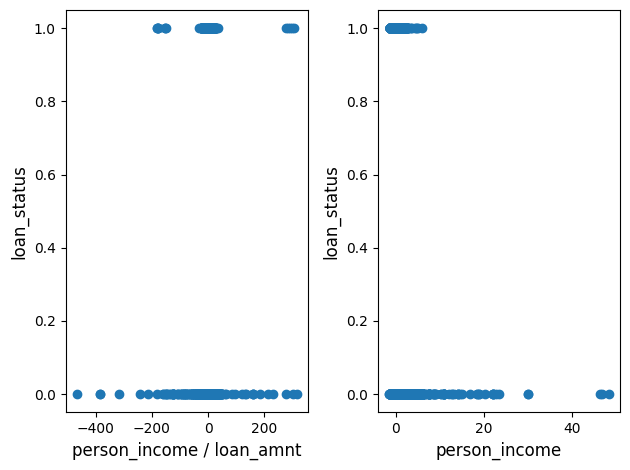

In [8]:
fig,ax = plt.subplots(1,2)

ax[0].scatter(df_train['person_income']/df_train['loan_amnt'], df_train['loan_status'])

ax[0].set_ylabel('loan_status', fontsize=12)
ax[0].set_xlabel('person_income / loan_amnt', fontsize=12)


ax[1].scatter(df_train['person_income'], df_train['loan_status'])

ax[1].set_ylabel('loan_status', fontsize=12)
ax[1].set_xlabel('person_income', fontsize=12)


plt.tight_layout() #this command is to automatically adjust so that the two plots don't overlap
plt.show()

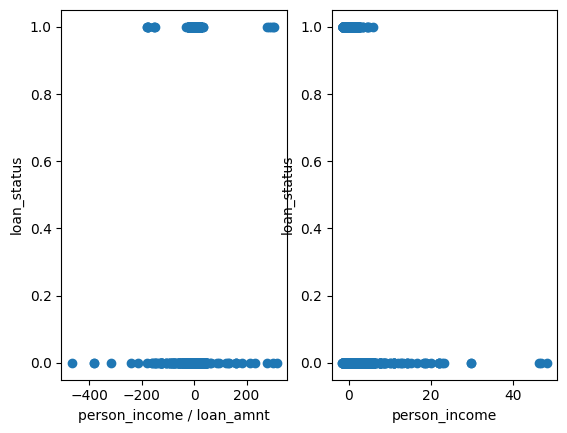

In [9]:
fig,ax = plt.subplots(1,2)

ax[0].scatter(df_train['person_income']/df_train['loan_amnt'], df_train['loan_status'])

ax[0].set_ylabel('loan_status')
ax[0].set_xlabel('person_income / loan_amnt')


ax[1].scatter(df_train['person_income'], df_train['loan_status'])

ax[1].set_ylabel('loan_status')
ax[1].set_xlabel('person_income')

plt.show()

In [10]:
df.loan_status.value_counts(normalize=True)

loan_status
0    0.857618
1    0.142382
Name: proportion, dtype: float64

array([[<Axes: title={'center': 'loan_amnt'}>,
        <Axes: title={'center': 'person_age'}>],
       [<Axes: title={'center': 'person_emp_length'}>, <Axes: >]],
      dtype=object)

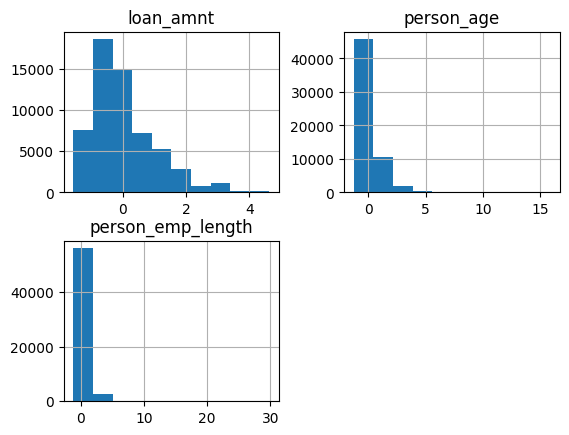

In [11]:
df[['loan_amnt','person_age','person_emp_length']].hist()

In [12]:
display(df.drop(['id','person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file'], axis=1).cov())
display(df.drop(['id','person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file'], axis=1).corr())



,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,loan_status
person_age,1.000000,0.102176,0.121276,0.050378,0.009653,-0.031975,0.874260,-0.000395
person_income,0.102176,1.000000,0.164042,0.310942,-0.057611,-0.280314,0.082727,-0.059390
person_emp_length,0.121276,0.164042,1.000000,0.092046,-0.101910,-0.065824,0.102842,-0.035094
loan_amnt,0.050378,0.310942,0.092046,1.000000,0.113582,0.647266,0.045720,0.050663
loan_int_rate,0.009653,-0.057611,-0.101910,0.113582,1.000000,0.152201,0.007535,0.118443
loan_percent_income,-0.031975,-0.280314,-0.065824,0.647266,0.152201,1.000000,-0.023202,0.132188
cb_person_cred_hist_length,0.874260,0.082727,0.102842,0.045720,0.007535,-0.023202,1.000000,-0.001059
loan_status,-0.000395,-0.059390,-0.035094,0.050663,0.118443,0.132188,-0.001059,0.122112


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,loan_status
person_age,1.000000,0.102176,0.121276,0.050378,0.009653,-0.031975,0.874260,-0.001130
person_income,0.102176,1.000000,0.164042,0.310942,-0.057611,-0.280314,0.082727,-0.169956
person_emp_length,0.121276,0.164042,1.000000,0.092046,-0.101910,-0.065824,0.102842,-0.100428
loan_amnt,0.050378,0.310942,0.092046,1.000000,0.113582,0.647266,0.045720,0.144982
loan_int_rate,0.009653,-0.057611,-0.101910,0.113582,1.000000,0.152201,0.007535,0.338948
loan_percent_income,-0.031975,-0.280314,-0.065824,0.647266,0.152201,1.000000,-0.023202,0.378280
cb_person_cred_hist_length,0.874260,0.082727,0.102842,0.045720,0.007535,-0.023202,1.000000,-0.003030
loan_status,-0.001130,-0.169956,-0.100428,0.144982,0.338948,0.378280,-0.003030,1.000000


In [13]:
import seaborn as sns

<Axes: >

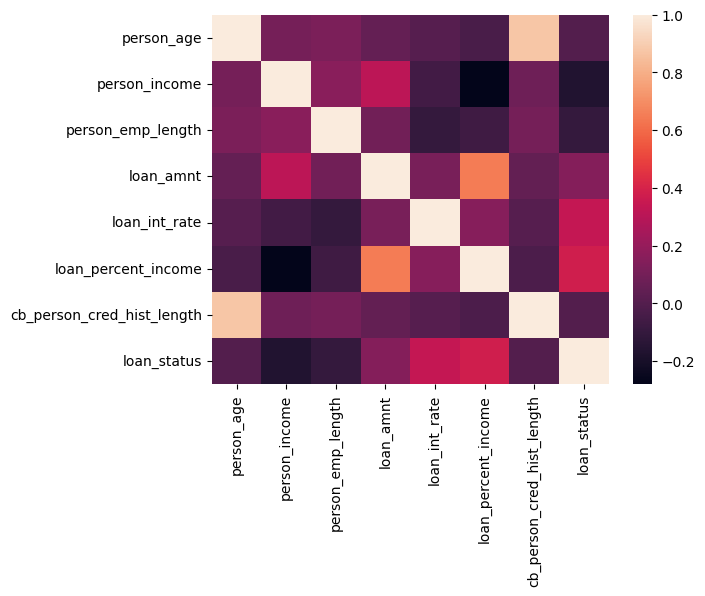

In [14]:
sns.heatmap(df.drop(['id','person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file'], axis=1).corr())

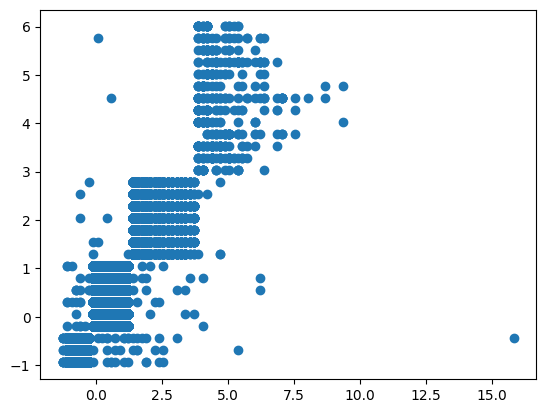

In [15]:
plt.scatter(df['person_age'],df['cb_person_cred_hist_length'])

<Axes: ylabel='Count'>

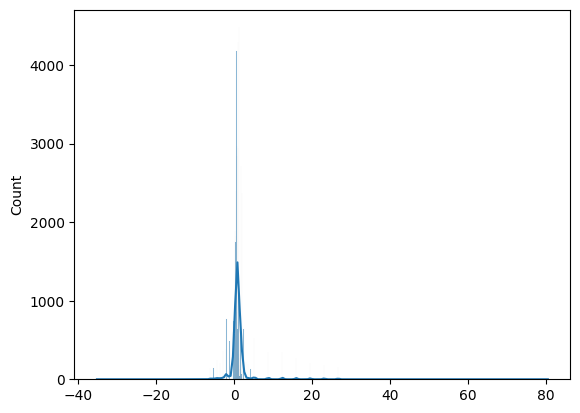

In [16]:
sns.histplot(df['person_age']/df['cb_person_cred_hist_length'],kde=True)

<Axes: ylabel='Count'>

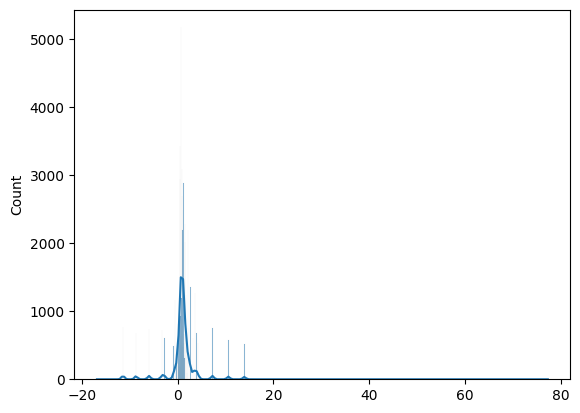

In [17]:
sns.histplot(df['cb_person_cred_hist_length']/df['person_age'],kde=True)

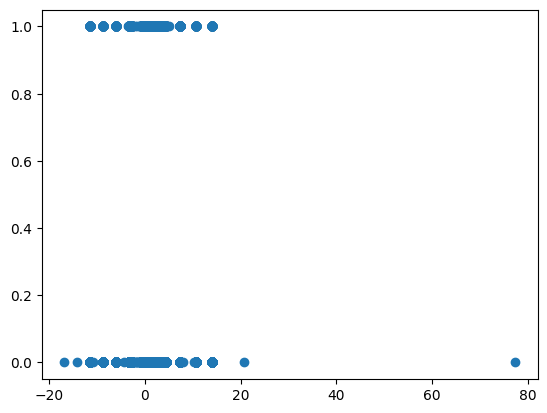

In [18]:
plt.scatter(x=df['cb_person_cred_hist_length']/df['person_age'],y=df['loan_status'])

In [19]:
df.loc[df['cb_person_cred_hist_length']/df['person_age']>.6]

,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,0,1.566187,-0.765761,RENT,-1.187190,EDUCATION,B,-0.578301,0.267613,0.117377,N,2.031781,0
1,1,-0.920049,-0.212126,OWN,0.328044,MEDICAL,C,-0.937767,0.880525,-0.973233,N,-0.946481,0
2,2,0.240194,-0.929216,OWN,0.833122,PERSONAL,A,-0.578301,-0.585849,0.553621,N,1.039027,0
4,4,-0.920049,-0.106672,RENT,-0.682112,MEDICAL,A,-0.578301,-1.238303,-0.646050,N,-0.698292,0
5,5,-0.091304,-0.502125,RENT,-0.682112,VENTURE,A,-0.039102,-0.572668,0.444560,N,-0.201915,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
58637,58637,-0.588551,0.288782,RENT,0.833122,VENTURE,B,-0.937767,0.023767,-1.191355,N,-0.450104,0
58640,58640,1.068940,1.475144,MORTGAGE,0.075505,EDUCATION,D,2.836627,1.737282,0.553621,Y,1.039027,0
58641,58641,0.074445,-0.929216,RENT,-1.187190,MEDICAL,C,0.140631,0.676221,2.080475,N,0.542650,1
58642,58642,-0.754300,-0.528489,RENT,0.580583,EDUCATION,D,-0.434515,1.753758,-0.100745,N,-0.946481,1


In [20]:
df.loc[df['person_age']>50]

,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status


In [21]:
#I've done some random plot involving the quantitative features we have. Here's how it went.

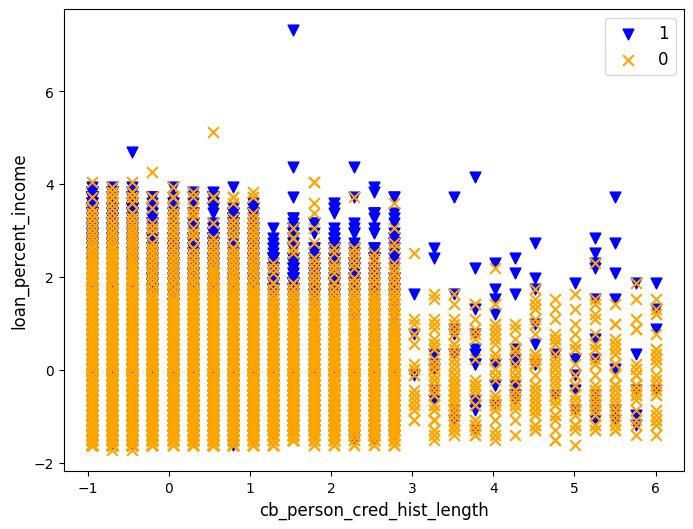

In [22]:
#First I started with loan_percent_income agains cb_person_cred_history_length
plt.figure(figsize=(8,6))

plt.scatter(df.loc[df.loan_status==1].cb_person_cred_hist_length,
            df.loc[df.loan_status==1].loan_percent_income,
            c='blue',
            s=60,
            marker='v',
            label="1")
plt.scatter(df.loc[df.loan_status==0].cb_person_cred_hist_length,
            df.loc[df.loan_status==0].loan_percent_income,
            c='orange',
            s=60,
            marker='x',
            label='0')
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlabel("cb_person_cred_hist_length", fontsize=12)
plt.ylabel("loan_percent_income", fontsize=12)
plt.legend(fontsize=12)

plt.show()

#It looks like there is a decreasing line in this graph above which the loans are granted. 
#This tendency is quite weak tho, but it will be clearer and clearer with the next plots.

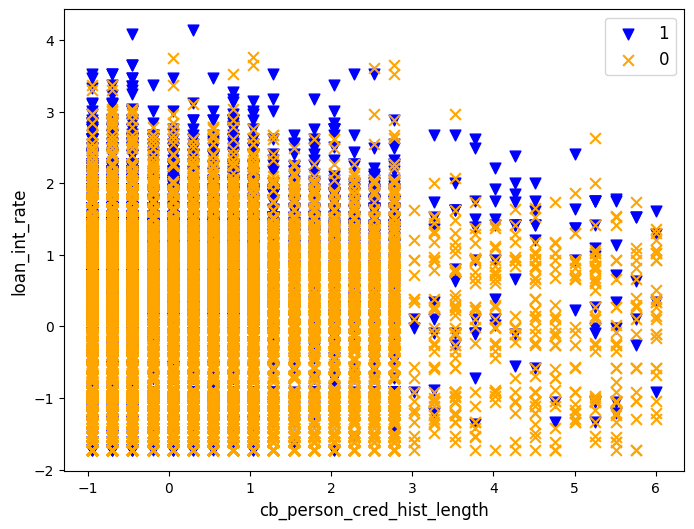

In [23]:
#Here we have loan_int_rate against cb_person_cred_hist_length.

plt.figure(figsize=(8,6))

plt.scatter(df.loc[df.loan_status==1].cb_person_cred_hist_length,
            df.loc[df.loan_status==1].loan_int_rate,
            c='blue',
            s=60,
            marker='v',
            label='1')

plt.scatter(df.loc[df.loan_status==0].cb_person_cred_hist_length,
            df.loc[df.loan_status==0].loan_int_rate,
            c='orange',
            s=60,
            marker='x',
            label='0')


plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlabel("cb_person_cred_hist_length", fontsize=12)
plt.ylabel("loan_int_rate", fontsize=12)
plt.legend(fontsize=12)

plt.show()

#As you can see this line above which the loan is granted gets clearer.

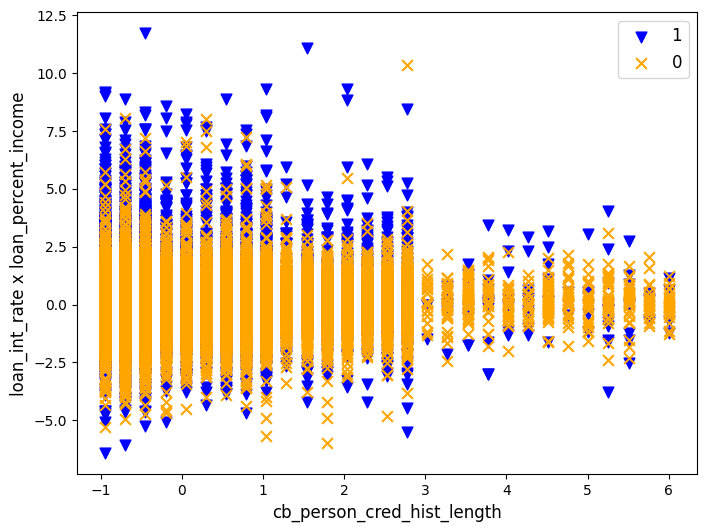

In [24]:
#At this point I've tried loan_int_rate * loan_percent_income against cb_person_cred_hist_length

plt.figure(figsize=(8,6))

plt.scatter(df.loc[df.loan_status==1].cb_person_cred_hist_length,
            df.loc[df.loan_status==1].loan_int_rate*df.loc[df.loan_status==1].loan_percent_income,
            c='blue',
            s=60,
            marker='v',
            label='1')

plt.scatter(df.loc[df.loan_status==0].cb_person_cred_hist_length,
            df.loc[df.loan_status==0].loan_int_rate*df.loc[df.loan_status==0].loan_percent_income,
            c='orange',
            s=60,
            marker='x',
            label='0')


plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlabel("cb_person_cred_hist_length", fontsize=12)
plt.ylabel("loan_int_rate x loan_percent_income", fontsize=12)
plt.legend(fontsize=12)

plt.show()

#I think here this line is much more clear. 
#One could try to find the slope of this line and use its intercept to 0 as a new feature. 
#The most interest behaviour is the next one tho.
#I've also tried to plot loan_int_rate / loan_percent_income agains cb_person_cred_hist_length and 
#loan_percent_income / loan_int_rate against cb_person_cred_hist_length, but I got less significative results.

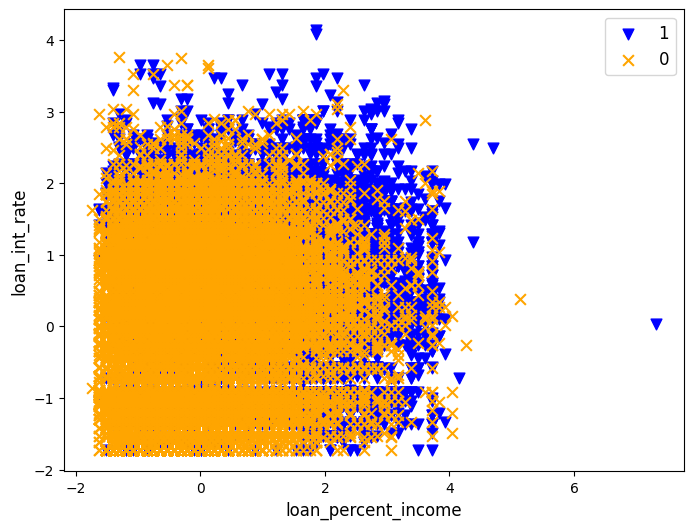

In [25]:
#Look what I get when I plot loan_int_rante against loan_percent_income
plt.figure(figsize=(8,6))

plt.scatter(df.loc[df.loan_status==1].loan_percent_income,
            df.loc[df.loan_status==1].loan_int_rate,
            c='blue',
            s=60,
            marker='v',
            label='1')

plt.scatter(df.loc[df.loan_status==0].loan_percent_income,
            df.loc[df.loan_status==0].loan_int_rate,
            c='orange',
            s=60,
            marker='x',
            label='0')


plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlabel("loan_percent_income", fontsize=12)
plt.ylabel("loan_int_rate", fontsize=12)
plt.legend(fontsize=12)

plt.show()

#It looks like there is some constant c such that if (loan_int_rante)^2+(loan_percent_income)^2>c, then the loan is granted.
#Therefore we might consider using (loan_int_rante)^2+(loan_percent_income)^2 as a nwe feature.

In [27]:
df['person_home_ownership'].value_counts

AttributeError: 'Series' object has no attribute 'values_count'

In [ ]:
#Look what I get when I plot loan_int_rante against loan_percent_income
plt.figure(figsize=(8,6))

plt.scatter(df.loc[df.loan_status==1].loan_percent_income,
            df.loc[df.loan_status==1].loan_int_rate,
            c='blue',
            s=60,
            marker='v',
            label='1')

plt.scatter(df.loc[df.loan_status==0].loan_percent_income,
            df.loc[df.loan_status==0].loan_int_rate,
            c='orange',
            s=60,
            marker='x',
            label='0')


plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlabel("loan_percent_income", fontsize=12)
plt.ylabel("loan_int_rate", fontsize=12)
plt.legend(fontsize=12)

plt.show()